In [16]:
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'openpyxl']:
  subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All libraries are ready!')

All libraries are ready!


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings


warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries imported successfully!')

Libraries imported successfully!


In [3]:
data = pd.read_excel(r"C:\Users\HomePC\Desktop\Analysis\Datasets\sales_records_dataset.xlsx")

In [4]:
data.head(5)

,order ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D
1,NaN,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C
3,ORD1004,Daniel Balogun,Female,East,Furniture,Bed,5.0,102967.0,514835.0,3286.0,87530.327068,NaN,Cash,Rep_B
4,ORD1005,Ibrahim Khan,Male,West,Electronics,Laptop,7.0,148887.0,1042209.0,741.0,67011.935599,2022-06-03,Transfer,Rep_D


In [5]:
data.tail(5)

,order ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
995,ORD1996,Ibrahim Abdullahi,Male,South,Books,Notebook,7.0,70489.0,NaN,418.0,24876.191878,2024-12-18,POS,Rep_A
996,ORD1997,Grace Ola,Male,North,Electronics,Phone,6.0,14019.0,84114.0,377.0,7147.160812,2023-08-30,POS,Rep_B
997,ORD1998,Aisha Okafor,Male,South,Furniture,Chair,3.0,20654.0,61962.0,4172.0,8027.172015,2024-12-21,Online,Rep_B
998,ORD1999,Ibrahim Musa,Female,West,Food,Snacks,5.0,113346.0,566730.0,2994.0,NaN,2023-05-03,Transfer,Rep_D
999,ORD2000,Tunde James,Female,West,Clothing,Jeans,9.0,55939.0,503451.0,265.0,118897.633070,2023-07-14,POS,Rep_B


In [6]:
data.columns

Index(['order ID', 'Customer_Name', 'Gender', 'Region', 'Product_Category',
       'Product_Name', 'Quantity', 'Unit_Price', 'Total_Sales', 'Discount',
       'Profit', 'Order_Date', 'Payment_Method', 'Sales_Rep'],
      dtype='object')

In [19]:
data.describe().round(2)

,Quantity,Unit_Price,Total_Sales,Discount,Profit
count,955.00,949.00,942.00,950.00,947.00
mean,5.53,75752.28,424735.26,2513.22,64645.40
std,2.85,42736.95,339359.57,1463.39,61028.39
min,1.00,2037.00,2118.00,0.00,171.57
25%,3.00,38059.00,133941.50,1271.00,17417.64
50%,6.00,76180.00,357334.50,2497.50,46940.54
75%,8.00,112145.00,621387.25,3796.25,93647.07
max,10.00,149555.00,1492040.00,4996.00,356652.16


In [21]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_data = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values('Missing %',
ascending=False)
print('Columns with missing values:')
print(missing_data.to_string())

Columns with missing values:
                  Missing Count  Missing %
Region                       59        5.9
Total_Sales                  58        5.8
Product_Category             56        5.6
Payment_Method               56        5.6
Order_Date                   55        5.5
Profit                       53        5.3
Gender                       51        5.1
Unit_Price                   51        5.1
Discount                     50        5.0
order ID                     45        4.5
Quantity                     45        4.5
Sales_Rep                    45        4.5
Customer_Name                44        4.4
Product_Name                 39        3.9


In [7]:
data.info

<bound method DataFrame.info of     order ID      Customer_Name  Gender Region Product_Category Product_Name  \
0    ORD1001       Zainab James  Female   West      Electronics       Laptop   
1        NaN      Zainab Okafor    Male   East         Clothing        Jeans   
2    ORD1003   Samuel Abdullahi    Male  South         Clothing        Shirt   
3    ORD1004     Daniel Balogun  Female   East        Furniture          Bed   
4    ORD1005       Ibrahim Khan    Male   West      Electronics       Laptop   
..       ...                ...     ...    ...              ...          ...   
995  ORD1996  Ibrahim Abdullahi    Male  South            Books     Notebook   
996  ORD1997          Grace Ola    Male  North      Electronics        Phone   
997  ORD1998       Aisha Okafor    Male  South        Furniture        Chair   
998  ORD1999       Ibrahim Musa  Female   West             Food       Snacks   
999  ORD2000        Tunde James  Female   West         Clothing        Jeans   

     Qu

In [8]:
data.isna()

,order ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,True,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,True,False,False,False


In [9]:
data.shape

(1000, 14)

### 

In [11]:
data.describe().round(2)

,Quantity,Unit_Price,Total_Sales,Discount,Profit
count,955.00,949.00,942.00,950.00,947.00
mean,5.53,75752.28,424735.26,2513.22,64645.40
std,2.85,42736.95,339359.57,1463.39,61028.39
min,1.00,2037.00,2118.00,0.00,171.57
25%,3.00,38059.00,133941.50,1271.00,17417.64
50%,6.00,76180.00,357334.50,2497.50,46940.54
75%,8.00,112145.00,621387.25,3796.25,93647.07
max,10.00,149555.00,1492040.00,4996.00,356652.16


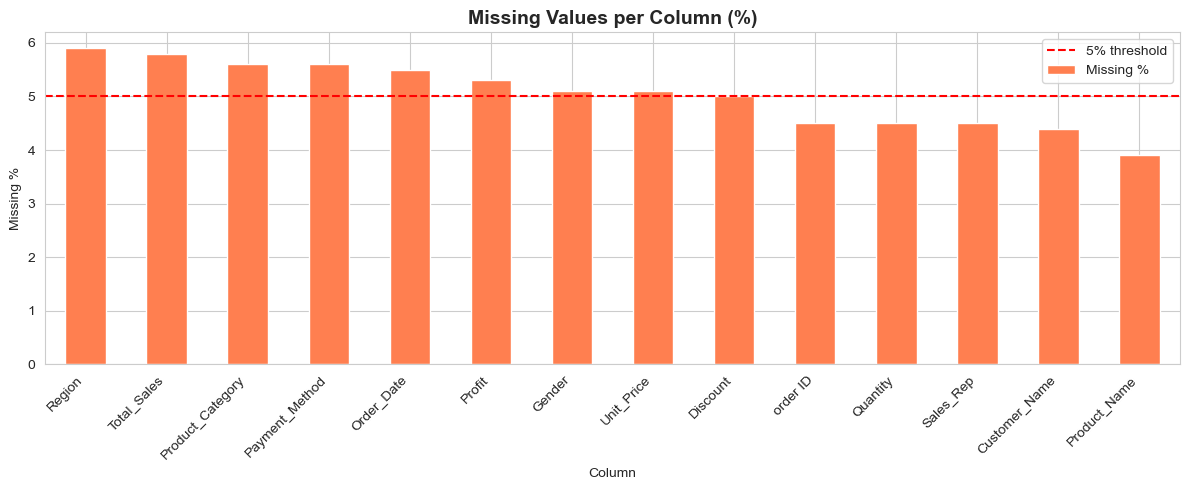

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
missing_data['Missing %'].plot(kind='bar', color='coral', ax=ax)
ax.set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Column')
ax.set_ylabel('Missing %')
ax.axhline(5, color='red', linestyle='--', label='5% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
cat_cols = ['Gender', 'Region', 'Product_Category', 'Payment_Method', 'Sales_Rep']
for col in cat_cols:
  print(f'\n📌 {col}:')
  print(data[col].value_counts(dropna=False).to_string())


📌 Gender:
Gender
Female    491
Male      458
NaN        51

📌 Region:
Region
South    258
East     239
West     232
North    212
NaN       59

📌 Product_Category:
Product_Category
Furniture      208
Electronics    204
Food           202
Clothing       184
Books          146
NaN             56

📌 Payment_Method:
Payment_Method
POS         253
Transfer    235
Online      234
Cash        222
NaN          56

📌 Sales_Rep:
Sales_Rep
Rep_D    251
Rep_A    249
Rep_C    230
Rep_B    225
NaN       45


In [22]:
# Check for duplicate rows
dupes = data.duplicated().sum()
print(f'Number of fully duplicate rows: {dupes}')

Number of fully duplicate rows: 0


In [28]:
# Make a working copy
data_clean = data.copy()
print(f'Working copy created. Shape: {data_clean.shape}')

Working copy created. Shape: (1000, 14)


In [29]:
# Fix the Order_Date column (text → datetime)
data_clean['Order_Date'] = pd.to_datetime(data_clean['Order_Date'], errors='coerce')

print('Order_Date dtype after fix:', data_clean['Order_Date'].dtype)
print('Sample dates:', data_clean['Order_Date'].dropna().head(5).tolist())

Order_Date dtype after fix: datetime64[ns]
Sample dates: [Timestamp('2022-07-18 00:00:00'), Timestamp('2024-09-18 00:00:00'), Timestamp('2023-09-11 00:00:00'), Timestamp('2022-06-03 00:00:00'), Timestamp('2023-07-12 00:00:00')]


In [31]:
# Remove duplicate rows
before = len(data_clean)
data_clean.drop_duplicates(inplace=True)
after = len(data_clean)

print(f'Rows before: {before} | After: {after} | Removed: {before - after}')

Rows before: 1000 | After: 1000 | Removed: 0


In [32]:
# Handle missing values in NUMERIC columns
data_clean['Quantity'] = data_clean['Quantity'].fillna(data_clean['Quantity'].median())
data_clean['Unit_Price'] = data_clean['Unit_Price'].fillna(data_clean['Unit_Price'].median())
data_clean['Total_Sales'] = data_clean['Total_Sales'].fillna(data_clean['Total_Sales'].median())
data_clean['Profit'] = data_clean['Profit'].fillna(data_clean['Profit'].median())
data_clean['Discount'] = data_clean['Discount'].fillna(0)

print('Numeric columns — remaining missing values:')
print(data_clean[['Quantity','Unit_Price','Total_Sales','Profit','Discount']].isnull(
).sum())

Numeric columns — remaining missing values:
Quantity       0
Unit_Price     0
Total_Sales    0
Profit         0
Discount       0
dtype: int64


In [27]:
#Handle missing values in CATEGORICAL columns
for col in ['Gender', 'Region', 'Product_Category', 'Payment_Method']:
  mode_val = data_clean[col].mode()[0]
  data_clean[col].fillna(mode_val)
    
for col in ['Sales_Rep', 'Customer_Name', 'order ID', 'Product_Name']:
  data_clean[col].fillna('Unknown')
    
data_clean.dropna(subset=['Order_Date'])

print('Remaining missing values after cleaning:')
print(data_clean.isnull().sum())

Remaining missing values after cleaning:
order ID            45
Customer_Name       44
Gender              51
Region              59
Product_Category    56
Product_Name        39
Quantity             0
Unit_Price           0
Total_Sales          0
Discount             0
Profit               0
Order_Date          55
Payment_Method      56
Sales_Rep           45
dtype: int64


In [43]:
data_clean['Year'] = data_clean['Order_Date'].dt.year
data_clean['Month'] = data_clean['Order_Date'].dt.month
data_clean['Month_Name'] = data_clean['Order_Date'].dt.strftime('%b')
data_clean['Quarter'] = data_clean['Order_Date'].dt.to_period('Q').astype(str)
data_clean['Profit_Margin'] = (data_clean['Profit'] / data_clean['Total_Sales'] *100).round(2)
print('New columns added:',
['Year','Month','Month_Name','Quarter','Profit_Margin'])
data_clean[['Order_Date','Year','Month','Month_Name','Quarter','Profit_Margin']].head()

New columns added: ['Year', 'Month', 'Month_Name', 'Quarter', 'Profit_Margin']


,Order_Date,Year,Month,Month_Name,Quarter,Profit_Margin
0,2022-07-18,2022.0,7.0,Jul,2022Q3,18.19
1,2024-09-18,2024.0,9.0,Sep,2024Q3,12.94
2,2023-09-11,2023.0,9.0,Sep,2023Q3,5.87
3,NaT,NaN,NaN,NaN,NaT,17.00
4,2022-06-03,2022.0,6.0,Jun,2022Q2,6.43


In [44]:
#Add derived (engineered) columns
data_clean['Year']                   = data_clean['Order_Date'].dt.year
data_clean['Month']                  = data_clean['Order_Date'].dt.month
data_clean['Month_Name']             = data_clean['Order_Date'].dt.strftime('%b')
data_clean['Quarter']                = data_clean['Order_Date'].dt.to_period('Q').astype(str)
data_clean['Profit_Margin']          = (data_clean['Profit'] / data_clean['Total_Sales'] * 100).round(2)

print('New columns added:', ['Year','Month','Month_Name','Quarter','Profit_Margin'])
data_clean[['Order_Date','Year','Month','Month_Name','Quarter','Profit_Margin']].head()


New columns added: ['Year', 'Month', 'Month_Name', 'Quarter', 'Profit_Margin']


,Order_Date,Year,Month,Month_Name,Quarter,Profit_Margin
0,2022-07-18,2022.0,7.0,Jul,2022Q3,18.19
1,2024-09-18,2024.0,9.0,Sep,2024Q3,12.94
2,2023-09-11,2023.0,9.0,Sep,2023Q3,5.87
3,NaT,NaN,NaN,NaN,NaT,17.00
4,2022-06-03,2022.0,6.0,Jun,2022Q2,6.43


In [45]:
#Final check after cleaning
print(f'Clean dataset shape: {data_clean.shape}')
print(f'Rows removed during cleaning: {len(data) - len(data_clean)}')
data_clean.head(5)

Clean dataset shape: (1000, 19)
Rows removed during cleaning: 0


,order ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep,Year,Month,Month_Name,Quarter,Profit_Margin
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D,2022.0,7.0,Jul,2022Q3,18.19
1,NaN,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A,2024.0,9.0,Sep,2024Q3,12.94
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C,2023.0,9.0,Sep,2023Q3,5.87
3,ORD1004,Daniel Balogun,Female,East,Furniture,Bed,5.0,102967.0,514835.0,3286.0,87530.327068,NaT,Cash,Rep_B,NaN,NaN,NaN,NaT,17.00
4,ORD1005,Ibrahim Khan,Male,West,Electronics,Laptop,7.0,148887.0,1042209.0,741.0,67011.935599,2022-06-03,Transfer,Rep_D,2022.0,6.0,Jun,2022Q2,6.43


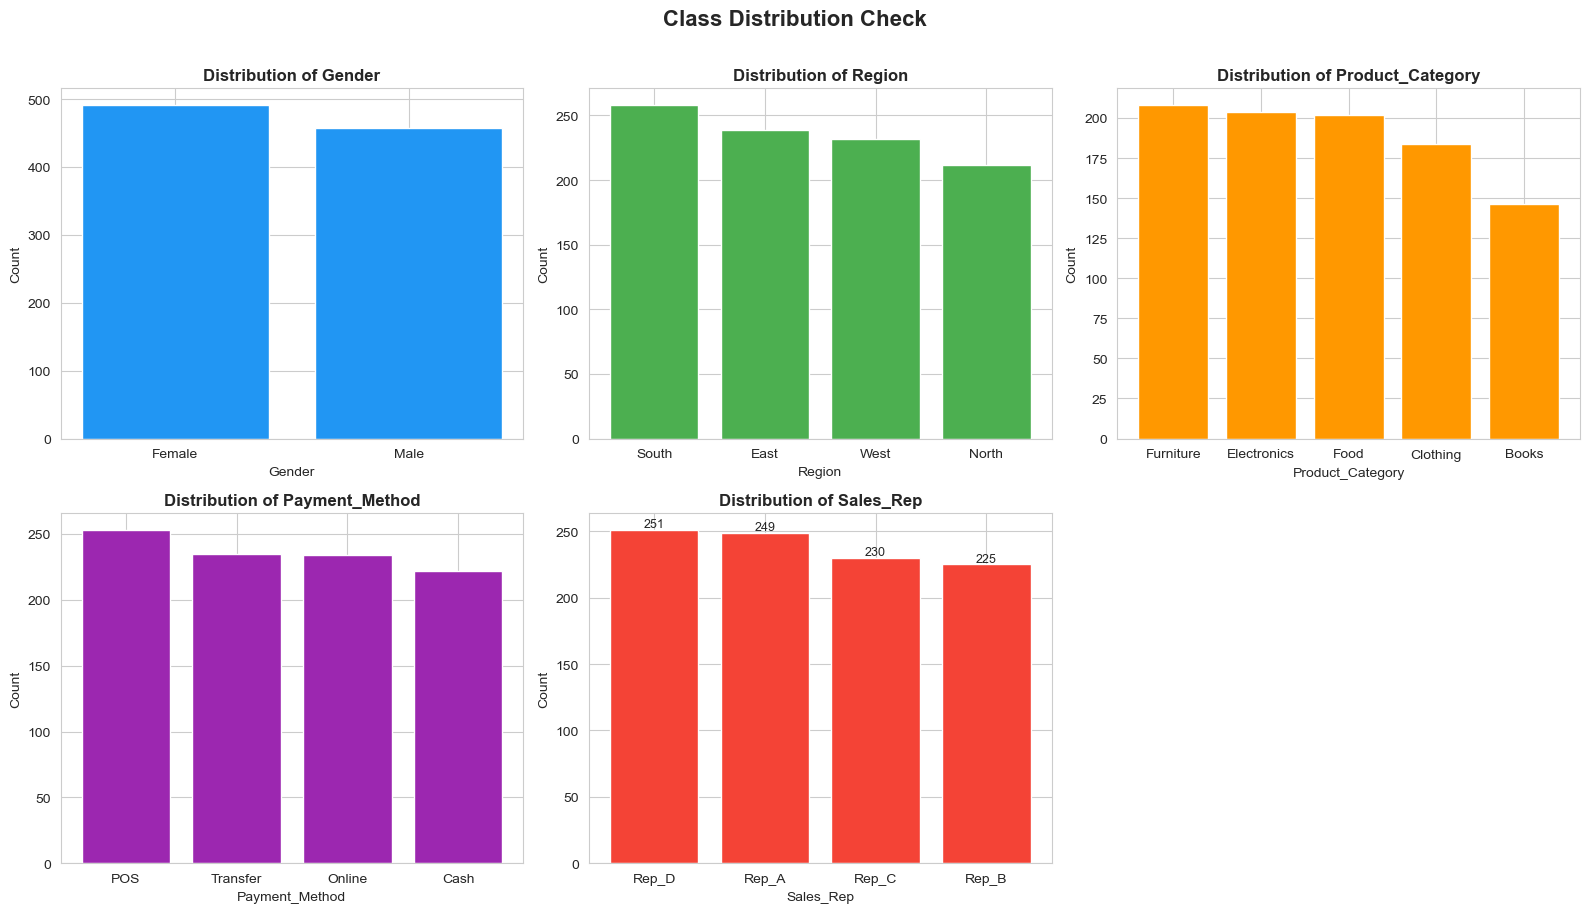

In [47]:
#Check distribution of key categorical columns
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cat_cols = ['Gender', 'Region', 'Product_Category', 'Payment_Method', 'Sales_Rep']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for i, col in enumerate(cat_cols):
  counts = data_clean[col].value_counts()
  axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='white')
  axes[i].set_title(f'Distribution of {col}', fontweight='bold')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')
    
for j, v in enumerate(counts.values):
  axes[i].text(j, v + 2, str(v), ha='center', fontsize=9)
  axes[5].set_visible(False)
plt.suptitle('Class Distribution Check', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [48]:
#Measure imbalance ratio
print('Imbalance Ratios (max / min count per category)\n')
for col in cat_cols:
 counts = data_clean[col].value_counts()
 ratio = counts.max() / counts.min()
 status = 'Balanced' if ratio <= 2.0 else '⚠️ Imbalanced'
 print(f'{col:<20} Ratio: {ratio:.2f} {status}')

Imbalance Ratios (max / min count per category)

Gender               Ratio: 1.07 Balanced
Region               Ratio: 1.22 Balanced
Product_Category     Ratio: 1.42 Balanced
Payment_Method       Ratio: 1.14 Balanced
Sales_Rep            Ratio: 1.12 Balanced


In [67]:
#Undersample to balance (demo)
APPLY_BALANCING = False # Change to True to activate
BALANCE_COLUMN = 'Product_Category'


if APPLY_BALANCING:
    min_count = data_clean[BALANCE_COLUMN].value_counts().min()
    data_balanced = (
      data_clean.groypby(BALANCE_COLUMN)
       .apply(lambda x: x.sample(min_ount, random_state=42))
    .reset_index(drop=True)
    )
    print(f'Balanced shape:{data_balanced.shape}')
    
    print(data_balanced[BALANCE_COLUMN].value_counts())

else:
    data_balanced = data_clean.copy()
    print('using the full cleaned dataset.')
    
    print(f'shape:{data_balanced.shape}')

using the full cleaned dataset.
shape:(1000, 19)


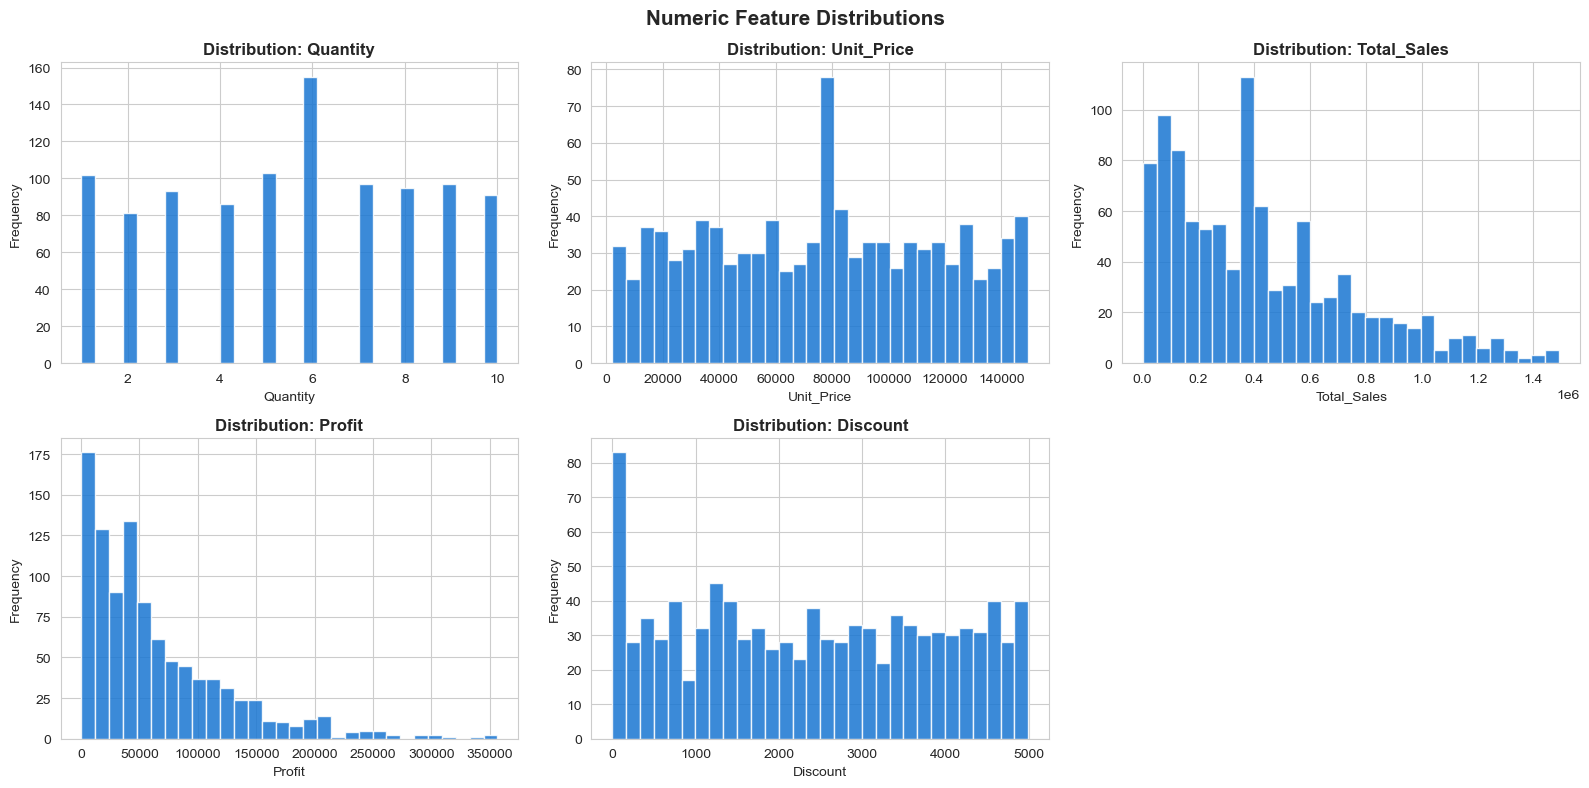

In [68]:
# Numeric feature distribution (histograms)
num_cols = ['Quantity', 'Unit_Price', 'Total_Sales', 'Profit', 'Discount']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
  axes[i].hist(data_balanced[col], bins=30, color='#1976D2',
  edgecolor='white', alpha=0.85)
  axes[i].set_title(f'Distribution: {col}', fontweight='bold')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Frequency')
axes[5].set_visible(False)
plt.suptitle('Numeric Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

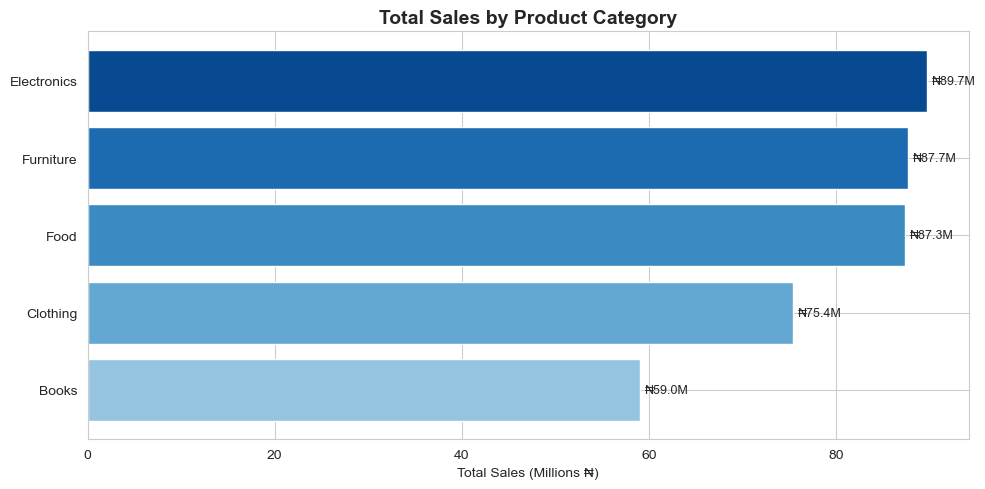

In [69]:
#Total Sales by Product Category
cat_sales = data_balanced.groupby('Product_Category')['Total_Sales'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(cat_sales)))
bars = ax.barh(cat_sales.index, cat_sales.values / 1e6, color=colors,
edgecolor='white')

for bar, val in zip(bars, cat_sales.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
        f'₦{val/1e6:.1f}M', va='center', fontsize=9)
    
ax.set_title('Total Sales by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales (Millions ₦)')
plt.tight_layout()
plt.show()

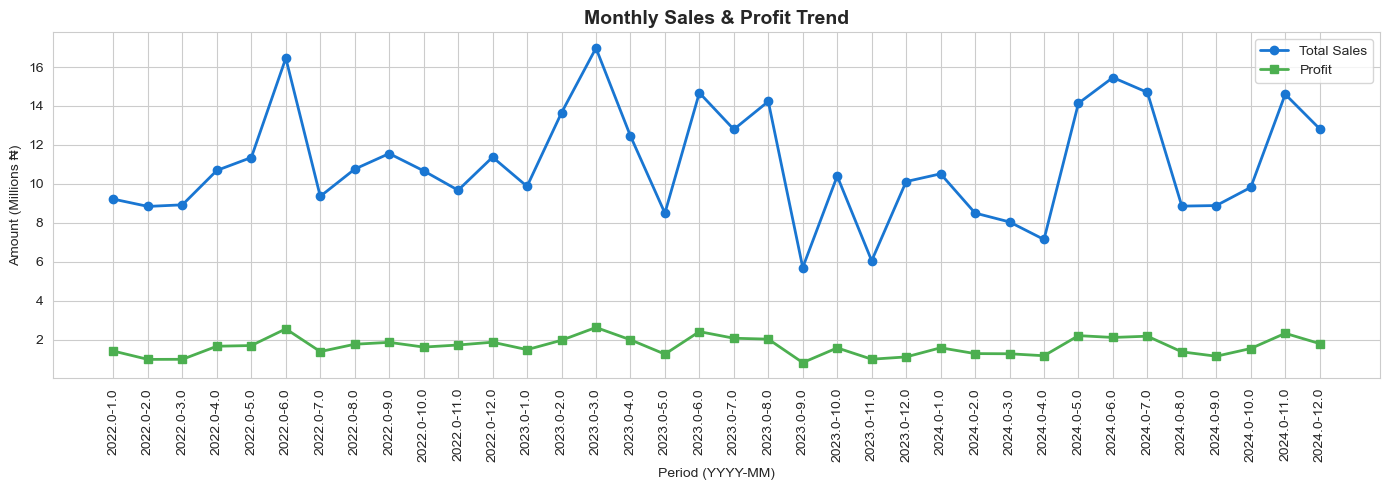

In [70]:
# Monthly Sales & Profit Trend
monthly = (
    data_balanced.groupby(['Year','Month'])[['Total_Sales','Profit']]
.sum().reset_index().sort_values(['Year','Month'])
)
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Period'], monthly['Total_Sales']/1e6,
          marker='o', color='#1976D2', label='Total Sales', linewidth=2)
ax.plot(monthly['Period'], monthly['Profit']/1e6,
          marker='s', color='#4CAF50', label='Profit', linewidth=2)
ax.set_title('Monthly Sales & Profit Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Period (YYYY-MM)')
ax.set_ylabel('Amount (Millions ₦)')
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

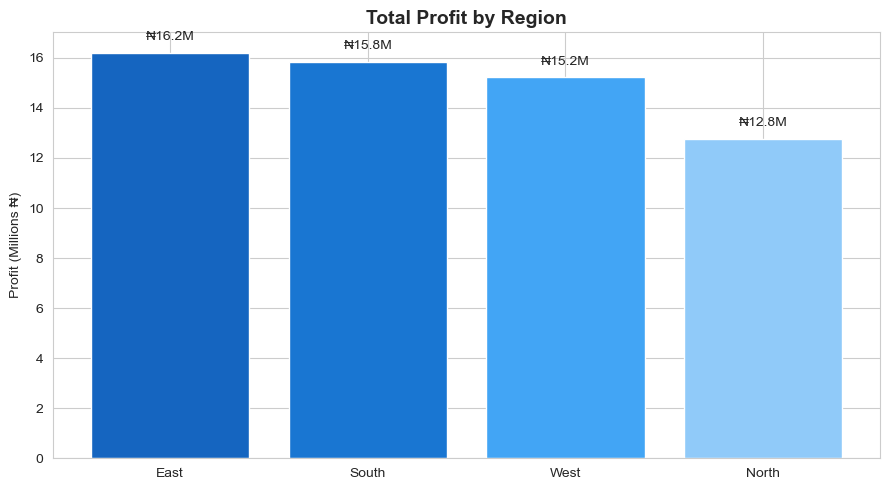

In [71]:
# Profit by Region
region_profit = data_balanced.groupby('Region')['Profit'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
palette = ['#1565C0','#1976D2','#42A5F5','#90CAF9']
bars = ax.bar(region_profit.index, region_profit.values/1e6, color=palette,
edgecolor='white')

for bar, val in zip(bars, region_profit.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
         f'₦{val/1e6:.1f}M', ha='center', fontsize=10)
    
ax.set_title('Total Profit by Region', fontsize=14, fontweight='bold')
ax.set_ylabel('Profit (Millions ₦)')
plt.tight_layout()
plt.show()

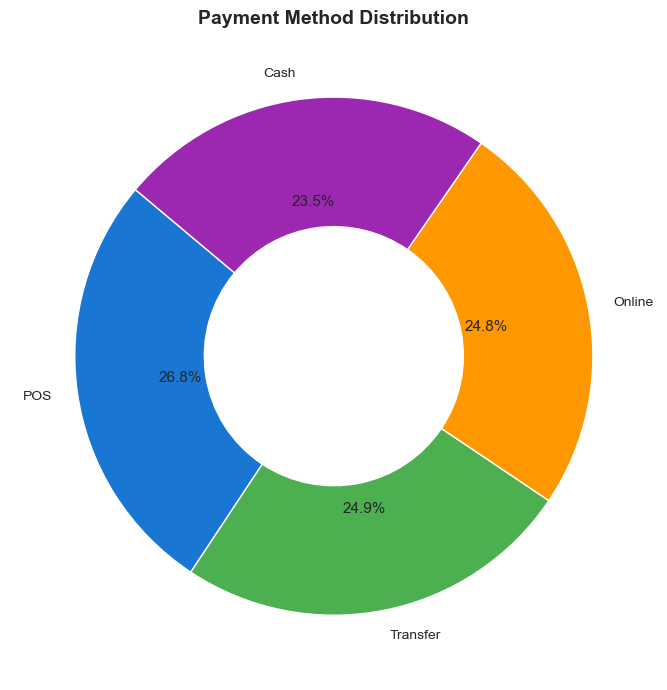

In [72]:
#Payment Method Share (Donut Chart)
pay_counts = data_balanced['Payment_Method'].value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    pay_counts.values,
    labels=pay_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'width': 0.5},
    colors=['#1976D2','#4CAF50','#FF9800','#9C27B0']
)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

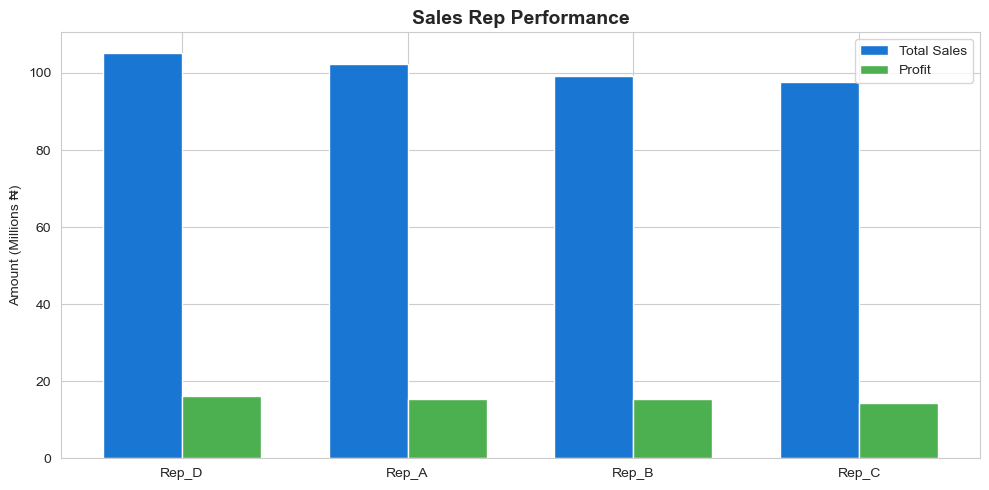

In [73]:
# Sales Rep Performance
rep_perf = (
data_balanced.groupby('Sales_Rep')[['Total_Sales','Profit']]
.sum().sort_values('Total_Sales', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(rep_perf)), 0.35

ax.bar(x - w/2, rep_perf['Total_Sales']/1e6, width=w, label='Total Sales',
color='#1976D2')
ax.bar(x + w/2, rep_perf['Profit']/1e6, width=w, label='Profit',
color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels(rep_perf.index)
ax.set_title('Sales Rep Performance', fontsize=14, fontweight='bold')
ax.set_ylabel('Amount (Millions ₦)')
ax.legend()
plt.tight_layout()
plt.show()

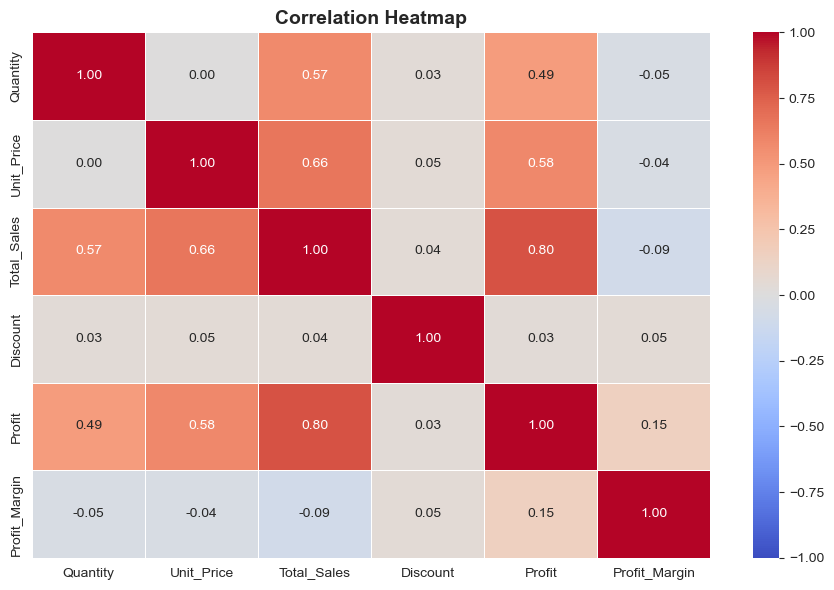

In [74]:
# Correlation Heatmap
corr = data_balanced[['Quantity','Unit_Price','Total_Sales',
'Discount','Profit','Profit_Margin']].corr()
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

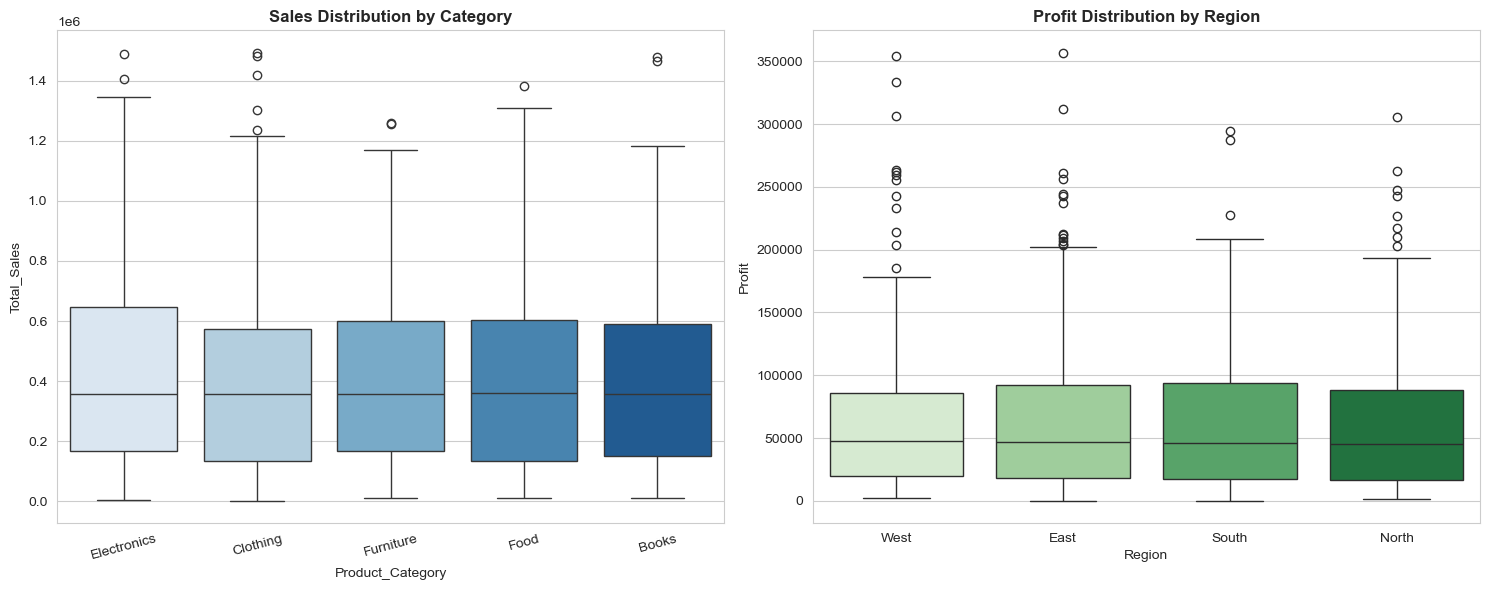

In [75]:
# Box Plots: Sales by Category & Region
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(data=data_balanced, x='Product_Category', y='Total_Sales',
 palette='Blues', ax=axes[0] )

axes[0].set_title('Sales Distribution by Category', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
sns.boxplot(data=data_balanced, x='Region', y='Profit', 
palette='Greens', ax=axes[1] )
axes[1].set_title('Profit Distribution by Region', fontweight='bold')
plt.tight_layout()
plt.show()

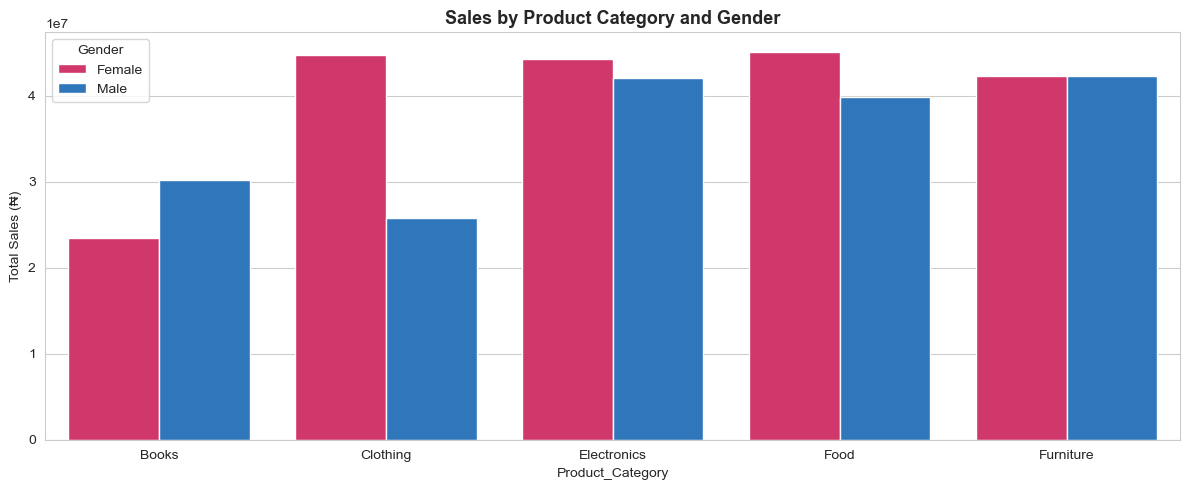

In [76]:
# Sales by Gender and Product Category
gender_cat = (
data_balanced.groupby(['Gender','Product_Category'])['Total_Sales']
.sum().reset_index()
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=gender_cat, x='Product_Category', y='Total_Sales',
hue='Gender',
palette={'Female':'#E91E63','Male':'#1976D2'}, ax=ax)
ax.set_title('Sales by Product Category and Gender', fontsize=13,
fontweight='bold')
ax.set_ylabel('Total Sales (₦)')
ax.legend(title='Gender')
plt.tight_layout()
plt.show()

In [77]:
#Prepare summary tables for the dashboard
# Monthly trend
monthly_trend = (
data_balanced.groupby(['Year','Month'])[['Total_Sales','Profit']]
.sum().reset_index().sort_values(['Year','Month'])
)
monthly_trend['Period'] = (monthly_trend['Year'].astype(str) + '-'+ monthly_trend['Month'].astype(str).str.zfill(2))
# Category summary
cat_summary = data_balanced.groupby('Product_Category').agg(
Total_Sales=('Total_Sales','sum'),
Profit=('Profit','sum'),
Orders=('order ID','count')
).reset_index()
# Region summary
region_summary = data_balanced.groupby('Region').agg(
Total_Sales=('Total_Sales','sum'),
Profit=('Profit','sum')
).reset_index()
# Sales Rep summary
rep_summary = data_balanced.groupby('Sales_Rep').agg(
Total_Sales=('Total_Sales','sum'),
Profit=('Profit','sum'),
Orders=('order ID','count')
).reset_index()
# Payment method
pay_summary = data_balanced['Payment_Method'].value_counts().reset_index()
pay_summary.columns = ['Payment_Method', 'Count']
print(' Summary tables ready!')

 Summary tables ready!


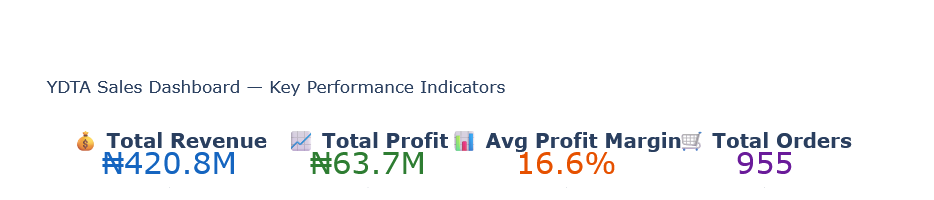

In [78]:
# KPI Summary Tiles
total_revenue = data_balanced['Total_Sales'].sum()
total_profit = data_balanced['Profit'].sum()
avg_margin = data_balanced['Profit_Margin'].mean()
total_orders = data_balanced['order ID'].nunique()
fig = go.Figure()
kpis = [
('💰 Total Revenue', f'₦{total_revenue/1e6:.1f}M', '#1565C0'),
('📈 Total Profit', f'₦{total_profit/1e6:.1f}M', '#2E7D32'),
('📊 Avg Profit Margin', f'{avg_margin:.1f}%', '#E65100'),
('🛒 Total Orders', f'{total_orders:,}', '#6A1B9A'),
]
for i, (label, value, color) in enumerate(kpis):
    fig.add_trace(go.Indicator(
mode='number',
value=None,
title={'text': f'<b>{label}</b><br>'
f'<span style="font-size:30px;color:{color}">{value}</span>',
'font': {'size': 20}},
domain={'row': 1, 'column': i}
))
fig.update_layout(
grid={'rows': 1, 'columns': 4},
height=200,
title='YDTA Sales Dashboard — Key Performance Indicators',
margin={'t': 600, 'b': 40}
)
fig.show()

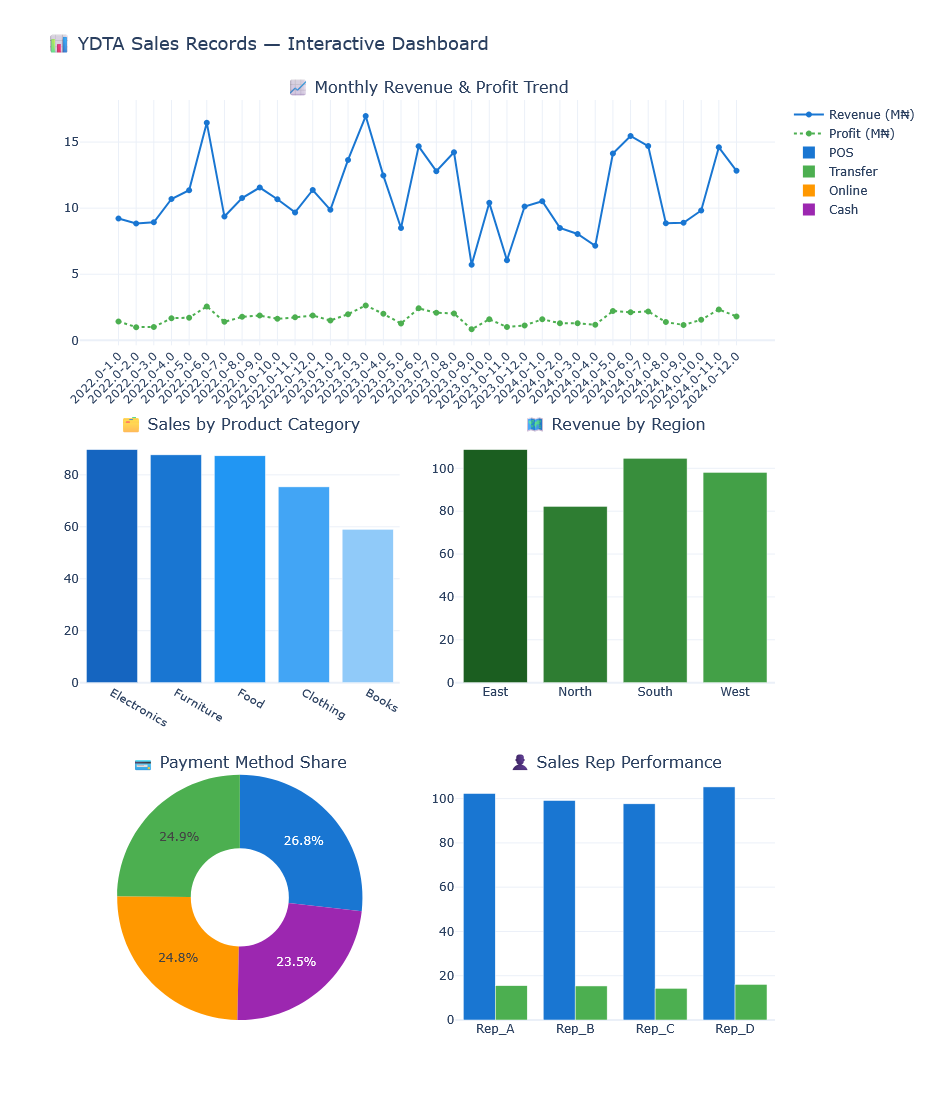

In [81]:
# Main 6-Panel Interactive Dashboard
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        '📈 Monthly Revenue & Profit Trend',
        '🗂️ Sales by Product Category',
        '🗺️ Revenue by Region',
        '💳 Payment Method Share',
        '👤 Sales Rep Performance',
        '🔥 Category vs Region Heatmap'
    ],
    specs=[
        [{'colspan': 2}, None],
        [{}, {}],
        [{'type': 'domain'}, {}]
    ],
    vertical_spacing=0.10,
    horizontal_spacing=0.08
)

# Panel 1: Monthly Trend
fig.add_trace(go.Scatter(
    x=monthly_trend['Period'],
    y=monthly_trend['Total_Sales']/1e6,
    mode='lines+markers',
    name='Revenue (M₦)',
    line=dict(color='#1976D2', width=2)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=monthly_trend['Period'],
    y=monthly_trend['Profit']/1e6,
    mode='lines+markers',
    name='Profit (M₦)',
    line=dict(color='#4CAF50', width=2, dash='dot')
), row=1, col=1)

# Panel 2: Category Sales
cat_s = cat_summary.sort_values('Total_Sales', ascending=False)
fig.add_trace(go.Bar(
    x=cat_s['Product_Category'],
    y=cat_s['Total_Sales']/1e6,
    name='Sales by Category',
    marker_color=['#1565C0','#1976D2','#2196F3','#42A5F5','#90CAF9'],
    showlegend=False
), row=2, col=1)

# Panel 3: Region Revenue
fig.add_trace(go.Bar(
    x=region_summary['Region'],
    y=region_summary['Total_Sales']/1e6,
    name='Sales by Region',
    marker_color=['#1B5E20','#2E7D32','#388E3C','#43A047'],
    showlegend=False
), row=2, col=2)

# Panel 4: Payment Method Pie
fig.add_trace(go.Pie(
    labels=pay_summary['Payment_Method'],
    values=pay_summary['Count'],
    hole=0.4,
    marker=dict(colors=['#1976D2','#4CAF50','#FF9800','#9C27B0'])
), row=3, col=1)

# Panel 5: Sales Rep
fig.add_trace(go.Bar(
    x=rep_summary['Sales_Rep'],
    y=rep_summary['Total_Sales']/1e6,
    name='Rep Revenue',
    marker_color='#1976D2',
    showlegend=False
), row=3, col=2)

fig.add_trace(go.Bar(
    x=rep_summary['Sales_Rep'],
    y=rep_summary['Profit']/1e6,
    name='Rep Profit',
    marker_color='#4CAF50',
    showlegend=False
), row=3, col=2)

fig.update_layout(
    height=1100,
    title_text='📊 YDTA Sales Records — Interactive Dashboard',
    title_font_size=18,
    template='plotly_white'
)
fig.update_xaxes(tickangle=-45, row=1, col=1)
fig.show()

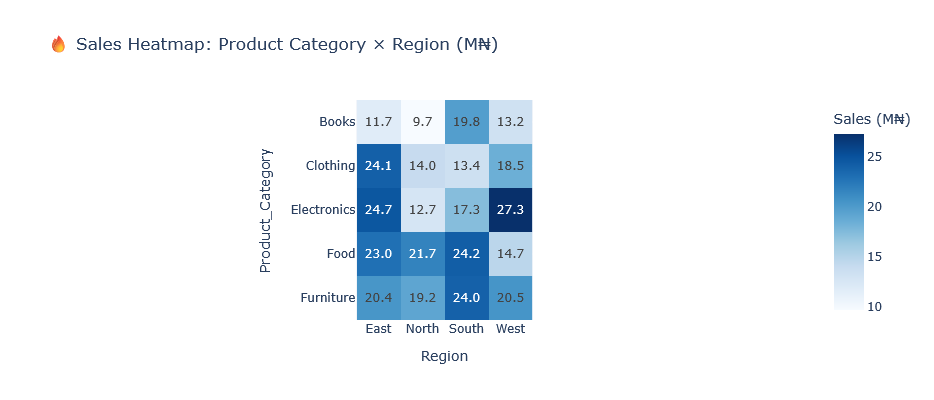

In [82]:
# Category × Region Heatmap
pivot = data_balanced.pivot_table(
values='Total_Sales', index='Product_Category',
columns='Region', aggfunc='sum'
) / 1e6
fig = px.imshow(
pivot, text_auto='.1f',
color_continuous_scale='Blues',
title='🔥 Sales Heatmap: Product Category × Region (M₦)',
labels={'color': 'Sales (M₦)'}
)
fig.update_layout(height=400)
fig.show()

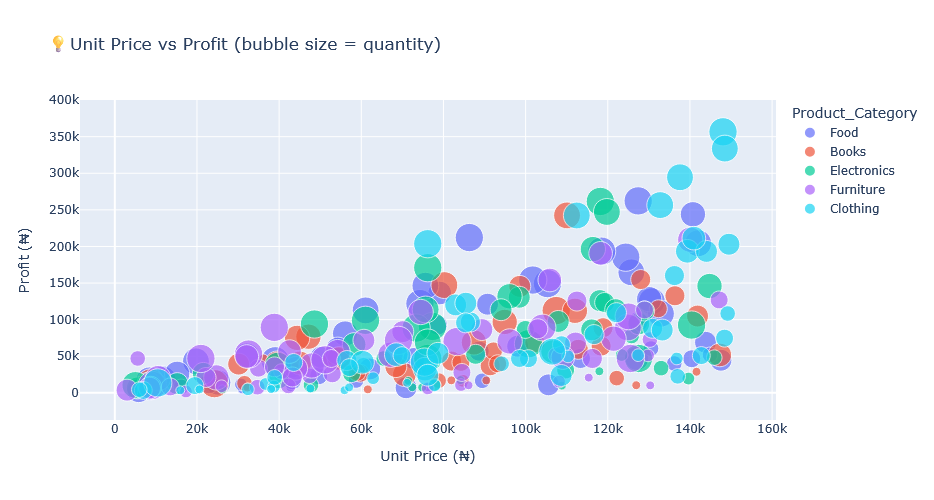

In [83]:
fig = px.scatter(
data_balanced.sample(300, random_state=42),
x='Unit_Price', y='Profit',
color='Product_Category',
size='Quantity',
hover_data=['Customer_Name','Region','Sales_Rep'],
title='💡Unit Price vs Profit (bubble size = quantity)',
labels={'Unit_Price':'Unit Price (₦)', 'Profit':'Profit (₦)'}
)
fig.update_layout(height=500)
fig.show()

In [84]:
output_path = 'sales_records_cleaned.xlsx'
data_balanced.to_excel(output_path, index=False)
print(f' Cleaned dataset saved to: {output_path}')
print(f' Final shape: {data_balanced.shape[0]:,} rows × {data_balanced.shape[1]}columns')

 Cleaned dataset saved to: sales_records_cleaned.xlsx
 Final shape: 1,000 rows × 19columns


In [85]:
#month that has the highest average profit margin
data_clean.dtypes

order ID                    object
Customer_Name               object
Gender                      object
Region                      object
Product_Category            object
Product_Name                object
Quantity                   float64
Unit_Price                 float64
Total_Sales                float64
Discount                   float64
Profit                     float64
Order_Date          datetime64[ns]
Payment_Method              object
Sales_Rep                   object
Year                       float64
Month                      float64
Month_Name                  object
Quarter                     object
Profit_Margin              float64
dtype: object

In [86]:
#month with the highest average profit_margin
data_clean['profit_margin'] =(data_clean['Profit']/data_clean['Total_Sales']) * 100
data_clean['Month']=data_clean['Order_Date'].dt.month
data_clean.groupby('Month')['profit_margin'].mean().sort_values(ascending=False)

Month
4.0     19.943659
1.0     18.985562
11.0    17.637947
8.0     16.512313
12.0    16.095205
7.0     15.843626
5.0     15.775986
3.0     15.762727
6.0     15.660115
9.0     15.080494
10.0    14.498364
2.0     14.095474
Name: profit_margin, dtype: float64

In [91]:
#sales_rep with the best profit margin 
rep_margin=data_clean.groupby('Sales_Rep').agg({
    'Profit':'sum',
    'Total_Sales':'sum'
})

rep_margin['Profit_Margin']=(rep_margin['Profit'] /
rep_margin['Total_Sales']) * 100

rep_margin.sort_values('Profit_Margin', ascending=False)

,Profit,Total_Sales,Profit_Margin
Sales_Rep,,,
Rep_B,1.537331e+07,99148187.0,15.505382
Rep_D,1.608301e+07,105277181.5,15.276827
Rep_A,1.550219e+07,102310803.5,15.152055
Rep_C,1.431329e+07,97641707.5,14.658990


In [94]:
# difference in discount across payment methods
data_clean.groupby('Payment_Method')['Discount'].mean().sort_values(ascending=False)

Payment_Method
Cash        2404.459459
POS         2366.355731
Online      2351.662393
Transfer    2349.991489
Name: Discount, dtype: float64

In [99]:
# which product_category has the most outliers in total_sales
import numpy as np

outliers = {}

for cat in data_clean['Product_Category'].unique():
    data = data_clean[data_clean['Product_Category'] == cat]['Total_Sales']
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers[cat] = ((data < lower) | (data > upper)).sum()

sorted(outliers.items(), key=lambda x: x[1], reverse=True)

[('Clothing', np.int64(5)),
 ('Electronics', np.int64(2)),
 ('Furniture', np.int64(2)),
 ('Books', np.int64(2)),
 ('Food', np.int64(1)),
 (nan, np.int64(0))]

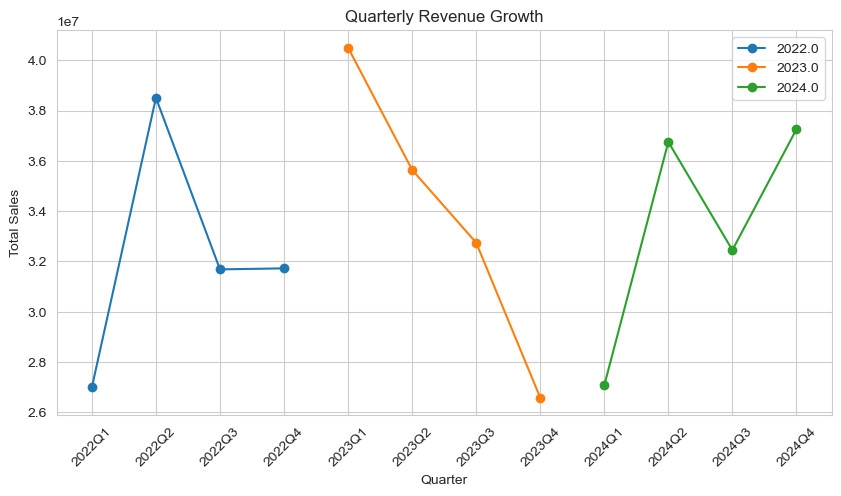

In [100]:
# quarterly revenue growth year-over-year
quarterly = data_clean.groupby(['Year', 'Quarter'])['Total_Sales'].sum().reset_index()

import matplotlib.pyplot as plt

for year in quarterly['Year'].unique():
    data = quarterly[quarterly['Year'] == year]
    plt.plot(data['Quarter'], data['Total_Sales'], marker='o', label=year)

plt.title('Quarterly Revenue Growth')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.legend()
plt.xticks(rotation=45)
plt.show()